# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica

**Integrantes:**

Artur Souza Pereira - RM 570880

Gustavo Gamba Zancopé - RM 569287

Isabela Camargo Souza - RM 569196

Miguel Silvério de Avila - RM 568873

Victor Vieira Galvão - RM 571483


**Objetivo:** construir e comparar dois modelos de **Regressão Linear** para prever o valor numérico da coluna `stab`, que mede a estabilidade de uma rede elétrica.

- **Modelo 1:** usa as 5 variáveis com maior correlação absoluta com `stab`.
- **Modelo 2:** usa todas as variáveis `tau` e `g` (8 variáveis).


## 1. Importação das bibliotecas

In [6]:
import numpy as np # para operações numéricas como valor absoluto e raiz quadrada
import pandas as pd # para carregar o CSV e manipular os dados em formato de tabela (DataFrame).
import matplotlib.pyplot as plt # para criar os gráficos: heatmap, gráficos de dispersão e gráficos de barras.
import seaborn as sns # para criar gráficos estatísticos mais elaborados

from sklearn.model_selection import train_test_split #Dividir os dados em treino e teste de forma aleatória e reproduzível.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error #para o cálculo das métricas R², MAE e MSE.

# Ajustes visuais gerais dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Carregamento e análise inicial do dataset

O dataset **Electrical Grid Stability Simulated Data** (UCI) simula uma rede elétrica com **4 nós** (1 produtor de energia e 3 consumidores). As colunas representam:

- tau1 a tau4: **tempo de reação** (em segundos) de cada participante da rede a mudanças de preço da energia;
- p1 a p4: **potência** produzida (valor positivo) ou consumida (valores negativos) por cada nó;
- g1 a g4: **coeficiente de elasticidade de preço** (*gamma*), ou seja, como cada participante reage ao preço;
- stab: **variável-alvo numérica** – parte real máxima da raiz da equação característica do sistema (se for positiva, o sistema é linearmente instável);
- stabf: rótulo categórico derivado de stab e possui duas classes (“stable” / “unstable”).

In [7]:
# Carregando o dataset em um DataFrame nomeado como df
url = 'https://raw.githubusercontent.com/Isa-souza07/Checkpoint_2-Modelo-de-Classificacao-com-Dados-de-Energia/refs/heads/main/Data_for_UCI_named.csv'
df = pd.read_csv(url)

# Primeiras linhas
df.head(10)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,unstable


In [8]:
# Quantidade de linhas e colunas
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 10000
Colunas: 14


In [9]:
df.info() # traz os nomes, tipos das colunas e contagem de valores não nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [10]:
# Valores ausentes por coluna
print(df.isnull().sum())
print("\nTotal de valores ausentes:", df.isnull().sum().sum())

tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Total de valores ausentes: 0


In [11]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tau1,10000.0,5.250000,2.742548,0.500793,2.874892,5.250004,7.624690,9.999469
tau2,10000.0,5.250001,2.742549,0.500141,2.875140,5.249981,7.624893,9.999837
tau3,10000.0,5.250004,2.742549,0.500788,2.875522,5.249979,7.624948,9.999450
tau4,10000.0,5.249997,2.742556,0.500473,2.874950,5.249734,7.624838,9.999443
p1,10000.0,3.750000,0.752160,1.582590,3.218300,3.751025,4.282420,5.864418
p2,10000.0,-1.250000,0.433035,-1.999891,-1.624901,-1.249966,-0.874977,-0.500108
p3,10000.0,-1.250000,0.433035,-1.999945,-1.625025,-1.249974,-0.875043,-0.500072
p4,10000.0,-1.250000,0.433035,-1.999926,-1.624960,-1.250007,-0.875065,-0.500025
g1,10000.0,0.525000,0.274256,0.050009,0.287521,0.525009,0.762435,0.999937
g2,10000.0,0.525000,0.274255,0.050053,0.287552,0.525003,0.762490,0.999944


In [12]:
# Conferências adicionais que ajudam a entender o dataset
print("Distribuição de stabf:")
print(df["stabf"].value_counts(), "\n")

Distribuição de stabf:
stabf
unstable    6380
stable      3620
Name: count, dtype: int64 



# **Registro da análise inicial** ###

**Quantidade de linhas:** 10.000 registros.

**Quantidade de colunas:** 14 (12 variáveis explicativas numéricas tau1–4, p1–4, g1–4, mais stab numérica e stabf categórica).  

**Existem valores ausentes?** Não. A soma de valores nulos é 0 em todas as colunas.

**Observações importantes sobre o dataset:**

1. **Tipos de dados:** as 13 primeiras colunas são float64 (numéricas) e apenas stabf é texto (*object/string*). Por isso, ao calcular correlação, é preciso considerar **somente as colunas numéricas**.

2. **stabf não será usada:** pois é o rótulo categórico (“stable”/“unstable”) usado em problemas de classificação. Como o objetivo é prever o valor numérico de stab, ela fica fora dos dois modelos.

3. **Escalas diferentes:** os dados da coluna `tau` variam de ~0,5 a ~10; os dados de `g` de ~0,05 a ~1; e os `p` de ~−2 a ~5,9. Como as escalas diferem, os coeficientes da regressão não são diretamente comparáveis entre `tau`, `g` e `p`.

4. **Alvo com valores pequenos:** `stab` tem média ≈ 0,0157 e desvio padrão ≈ 0,0369 (de ≈ −0,081 a ≈ 0,109). Por isso, é esperado que MAE e MSE também sejam números pequenos.

5. **Distribuição uniforme das variáveis:** `tau` e `g` têm médias idênticas entre si (5,25 e 0,525) e quartis regulares, o que é típico de dados **simulados** com sorteio uniforme.

6. **Distribuição de `stabf`:** há 6.380 registros “unstable” (63,8%) e 3.620 “stable” (36,2%), isto é, mais simulações instáveis do que estáveis. Isso ajuda a entender por que a média de `stab` é ligeiramente positiva.

## 3. Definição da variável target

A variável que os modelos devem prever é `stab`. Criar a variável y com essa coluna e apresentar seus primeiros valores.

In [13]:
# Variável alvo
y = df["stab"]

y.head(10)

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860
5,-0.017385
6,0.005954
7,0.016634
8,-0.038677
9,0.012383


In [14]:
print("Formato de y:", y.shape) # a quantidade de dados de y
print("Mín:", round(y.min(), 4), "| Máx:", round(y.max(), 4), "| Média:", round(y.mean(), 4)) # mostra o menor valor, o maior e a média com 4 casas decimais

Formato de y: (10000,)
Mín: -0.0808 | Máx: 0.1094 | Média: 0.0157


## 4. Matriz de correlação

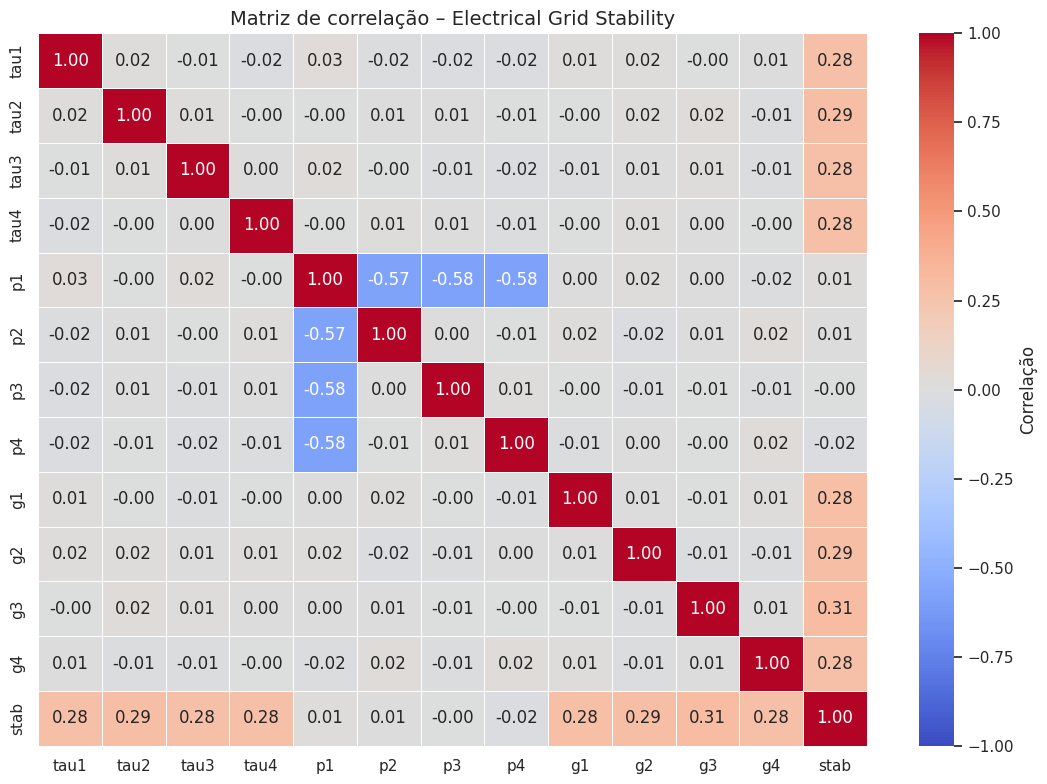

In [15]:
# Somente colunas numéricas (exclui stabf, que é texto)
df_num = df.select_dtypes(include="number")

# Matriz de correlação
matriz_corr = df_num.corr()

# Mapa de calor
plt.figure(figsize=(11, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"label": "Correlação"})
plt.title("Matriz de correlação – Electrical Grid Stability", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Correlação de cada variável com stab (sem ser a própria stab), ordenada pelo valor absoluto
corr_stab = matriz_corr["stab"].drop("stab") # pega só a coluna stab da matriz de correlação e remove a linha da própria stab
corr_ordenada = corr_stab.reindex(corr_stab.abs().sort_values(ascending=False).index) # descobre a ordem das variáveis pelo valor absoluto da correlação, do maior para o menor, e reorganiza corr_stab nessa ordem mantendo os valores originais com sinal (positivo ou negativo).
corr_ordenada.to_frame("Correlação com stab").round(4) # transforma o resultado em uma tabela (DataFrame) com a coluna chamada "Correlação com stab" e arredonda os valores para 4 casas decimais.

,Correlação com stab
g3,0.3082
g2,0.2936
tau2,0.2910
g1,0.2828
tau3,0.2807
g4,0.2792
tau4,0.2786
tau1,0.2758
p4,-0.0208
p1,0.0103


In [17]:
# As cinco variáveis com maior correlação absoluta
top5 = corr_ordenada.head(5)
print("Cinco maiores correlações absolutas com stab:\n")
print(top5.round(4))

Cinco maiores correlações absolutas com stab:

g3      0.3082
g2      0.2936
tau2    0.2910
g1      0.2828
tau3    0.2807
Name: stab, dtype: float64


## 5. Apoio do Gemini para seleção e visualização das variáveis

As 5 variáveis com maior correlação absoluta com 'stab':

Variável: g3     | Correlação Original: +0.3082
Variável: g2     | Correlação Original: +0.2936
Variável: tau2   | Correlação Original: +0.2910
Variável: g1     | Correlação Original: +0.2828
Variável: tau3   | Correlação Original: +0.2807

Lista 'cinco_variaveis' = ['g3', 'g2', 'tau2', 'g1', 'tau3']



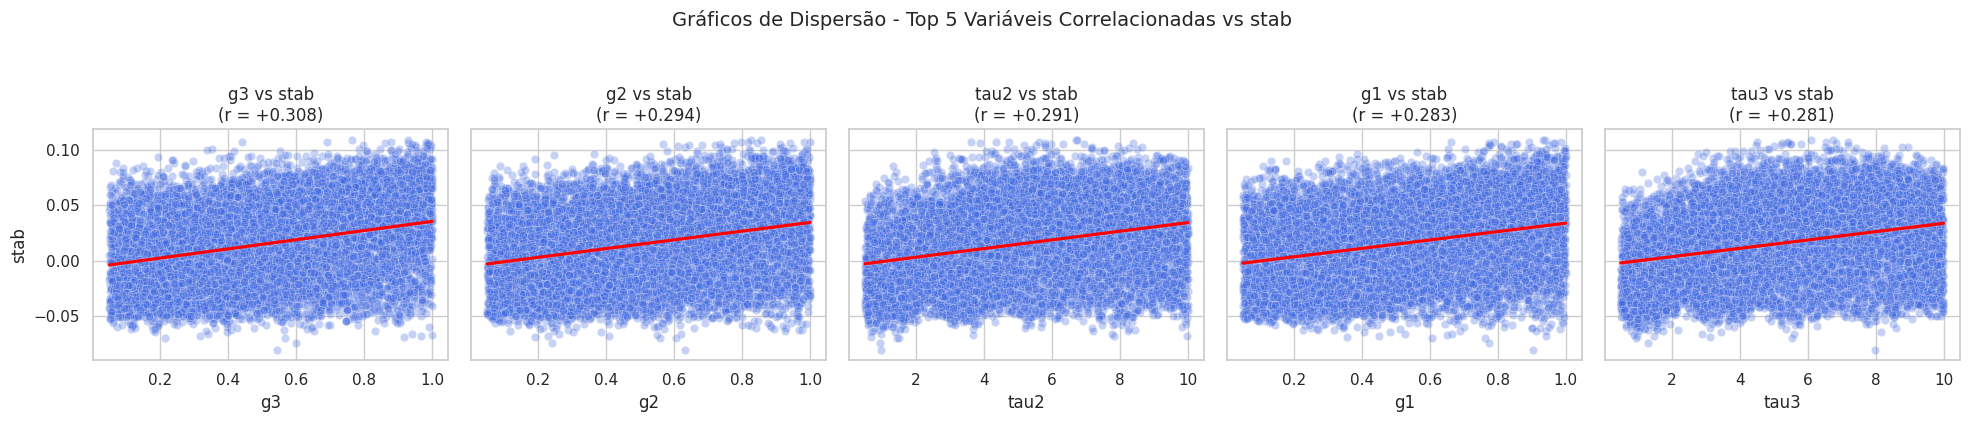

In [18]:
#---------------------------------------CÓDIGO GEMINI---------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# (1) Calcula a correlação das variáveis numéricas com stab
# (2) Desconsidera a própria coluna 'stab'
correlacoes = df.select_dtypes(include='number').corr()['stab'].drop('stab')

# (3) Usa o valor absoluto para identificar as cinco variáveis com maior correlação
cinco_maiores_abs = correlacoes.abs().nlargest(5)

# (5) Armazena os nomes dessas variáveis em uma lista chamada cinco_variaveis
cinco_variaveis = cinco_maiores_abs.index.tolist()

# (4) Apresenta os nomes das cinco variáveis e os valores originais de correlação (com sinal)
print("As 5 variáveis com maior correlação absoluta com 'stab':\n")
for var in cinco_variaveis:
    valor_original = correlacoes[var]
    print(f"Variável: {var:<6} | Correlação Original: {valor_original:+.4f}")

print(f"\nLista 'cinco_variaveis' = {cinco_variaveis}\n")

# (6) Cria cinco gráficos de dispersão, um para cada variável selecionada (X = variável, Y = stab)
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for i, var in enumerate(cinco_variaveis):
    sns.scatterplot(data=df, x=var, y='stab', alpha=0.3, ax=axes[i], color='royalblue')
    # Adicionando uma linha de regressão para melhor visualização da tendência
    sns.regplot(data=df, x=var, y='stab', scatter=False, color='red', ax=axes[i])
    axes[i].set_title(f"{var} vs stab\n(r = {correlacoes[var]:+.3f})")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('stab' if i == 0 else '')

plt.suptitle("Gráficos de Dispersão - Top 5 Variáveis Correlacionadas vs stab", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

Cinco variáveis com maior |correlação| com stab:

1º  g3    correlação = +0.3082
2º  g2    correlação = +0.2936
3º  tau2  correlação = +0.2910
4º  g1    correlação = +0.2828
5º  tau3  correlação = +0.2807

cinco_variaveis = ['g3', 'g2', 'tau2', 'g1', 'tau3']


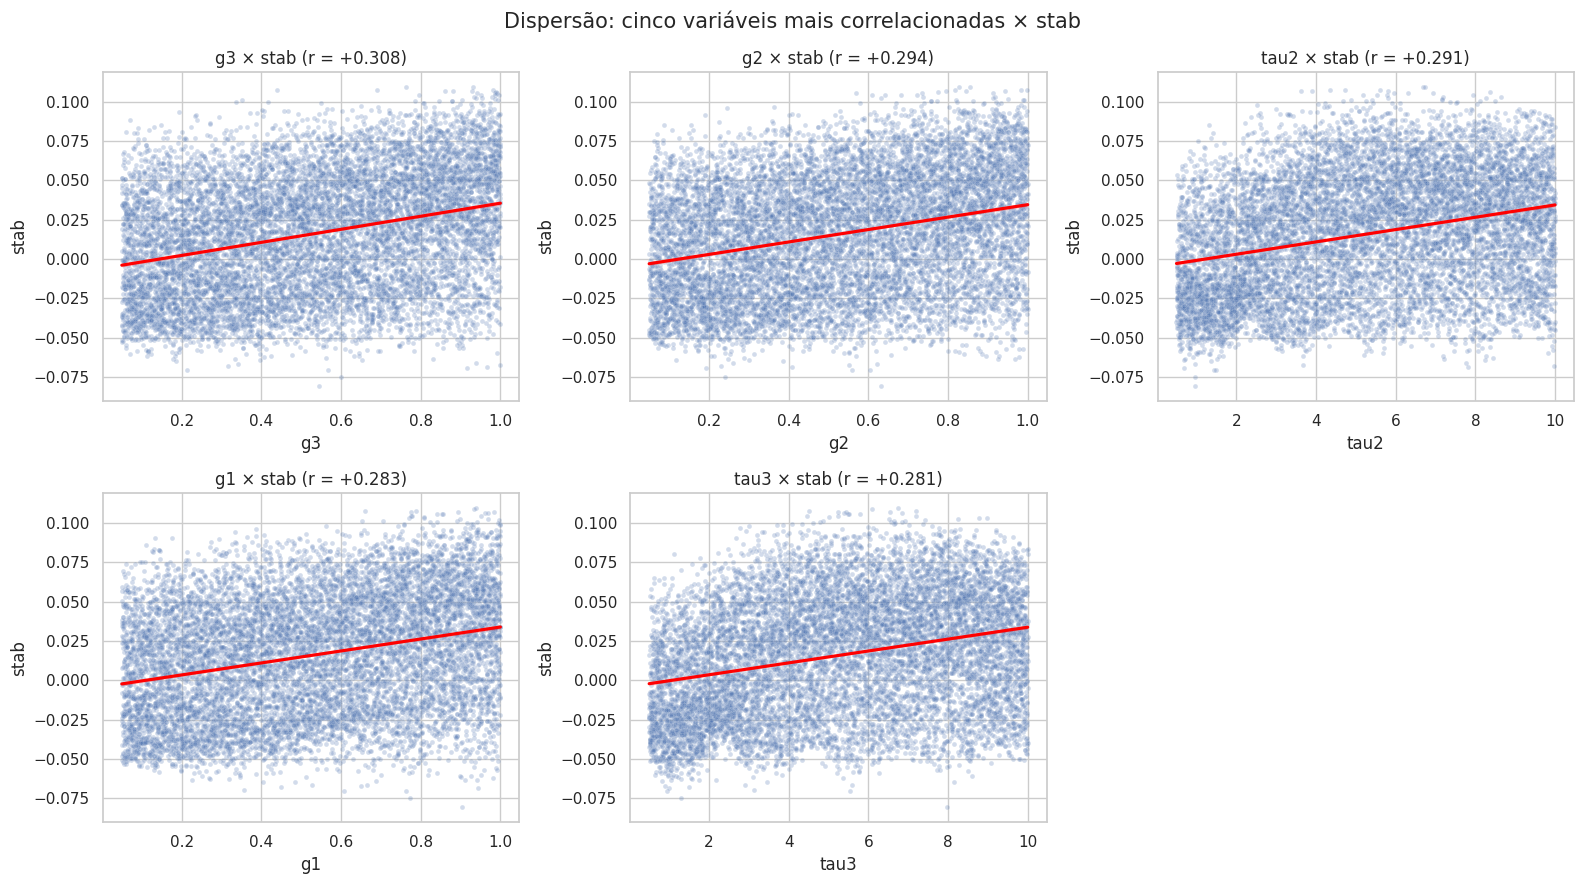

In [19]:
#---------------------------------------CÓDIGO REVISADO--------------------------------------------

# (1) e (2) Cálculo da correlação das variáveis numéricas com stab, desconsiderando
# a própria coluna stab
correlacoes = df.select_dtypes(include="number").corr()["stab"].drop("stab")

# (3) Ordena pelo valor absoluto e pega as cinco variáveis com maior correlação com stab
cinco_maiores = correlacoes.reindex(correlacoes.abs().sort_values(ascending=False).index).head(5)

# (4) Nomes e valores originais
print("Cinco variáveis com maior |correlação| com stab:\n")
for i, (nome, valor) in enumerate(cinco_maiores.items(), start=1):
    print(f"{i}º  {nome:<5} correlação = {valor:+.4f}")

# (5) Armazenando os nomes dessas variáveis em uma lista de nome cinco_variaveis
cinco_variaveis = cinco_maiores.index.tolist()
print("\ncinco_variaveis =", cinco_variaveis)

# (6) Criação dos cinco gráficos de dispersão: variável no eixo X, stab no eixo Y
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, var in zip(axes, cinco_variaveis):
    sns.scatterplot(data=df, x=var, y="stab", alpha=0.25, s=12, ax=ax)
    # Linha de tendência linear para facilitar a leitura
    sns.regplot(data=df, x=var, y="stab", scatter=False, color="red", ax=ax)
    ax.set_title(f"{var} × stab (r = {correlacoes[var]:+.3f})")
    ax.set_xlabel(var)
    ax.set_ylabel("stab")

axes[-1].axis("off")  # o 6º espaço da grade fica vazio
plt.suptitle("Dispersão: cinco variáveis mais correlacionadas × stab", fontsize=15)
plt.tight_layout()
plt.show()

### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 | `g3` | +0,3082 |
| 2 | `g2` | +0,2936 |
| 3 | `tau2` | +0,2910 |
| 4 | `g1` | +0,2828 |
| 5 | `tau3` | +0,2807 |



**Qual variável apresentou a maior correlação absoluta com `stab`?**
A variável com maior correlação absoluta foi **`g3`**, com correlação de **+0,3082**. O sinal é positivo, então valores maiores de g3 tendem a vir acompanhados de valores maiores de `stab`. Como `stab` positivo significa sistema instável, **maior `g3` está associado a maior instabilidade**. Assim,como o valor está longe de 1, a relação é fraca a moderada: g3 sozinha não é suficiente para prever stab.


**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Nos cinco gráficos vê-se um aglomerado de pontos com inclinação positiva (a linha vermelha de tendência sobe da esquerda para a direita). Isso confirma a correlação positiva, mas também mostra que a relação é **fraca a moderada**: para um mesmo valor de `g3` (ou `tau2` etc.) existe uma grande dispersão vertical de `stab`, variando de valores negativos (estável) a positivos (instável). Ou seja, nenhuma variável sozinha prevê bem `stab`. O efeito é **cumulativo**: a estabilidade depende de várias variáveis ao mesmo tempo, o que justifica usar regressão **múltipla**. Os gráficos dos `g` e dos `tau` têm formato muito parecido, reforçando que todas essas variáveis contribuem de forma semelhante.

# Modelo 1 – Cinco maiores correlações

Agora montamos `X` **somente** com as cinco variáveis escolhidas na etapa anterior. A variável `y` continua sendo `stab`.

Usar `X` (maiúsculo, matriz com várias colunas) e `y` (minúsculo, vetor) é a convenção do scikit-learn. Esta é uma estratégia de **seleção de variáveis por filtro (*filter*)**: escolhemos as variáveis pela correlação **antes** de treinar o modelo.

In [20]:
# X utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação
X = df[cinco_variaveis]

print("Variáveis em X:", list(X.columns))
print("Formato de X:", X.shape, "| Formato de y:", y.shape, "\n")
#primeiras linhas de X
X.head()

Variáveis em X: ['g3', 'g2', 'tau2', 'g1', 'tau3']
Formato de X: (10000, 5) | Formato de y: (10000,) 



,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759


In [21]:
#primeiras linhas de y (stab)
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 6. Separação entre treino e teste

In [32]:
#Separando X e y com random_state utilizando 80% dos dados para treinamento e 20% para teste para ambos
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

print("Registros de treino (X):", X_treino.shape[0], f"({X_treino.shape[0]/len(df):.0%})")
print("Registros de teste (X):", X_teste.shape[0],  f"({X_teste.shape[0]/len(df):.0%})")
print("Registros de treino (Y):", y_treino.shape[0], f"({y_treino.shape[0]/len(df):.0%})")
print("Registros de teste (Y):", y_teste.shape[0],  f"({y_teste.shape[0]/len(df):.0%})")

Registros de treino (X): 8000 (80%)
Registros de teste (X): 2000 (20%)
Registros de treino (Y): 8000 (80%)
Registros de teste (Y): 2000 (20%)


## 7. Treinamento e previsões do Modelo 1

In [23]:
# Criação e treinamento do modelo
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)

# Previsões no conjunto de teste
y_previsao_1 = modeloLR.predict(X_teste)

# Equação aprendida
print("Intercepto (β0):", round(modeloLR.intercept_, 5))
print("\nCoeficientes:")
for nome, coef in zip(X.columns, modeloLR.coef_):
    print(f"  {nome:<5} β = {coef:+.5f}")

# Comparação visual de alguns valores reais × previstos
pd.DataFrame({"stab real": y_teste.values[:8], "stab previsto": y_previsao_1[:8]}).round(4)

Intercepto (β0): -0.08603

Coeficientes:
  g3    β = +0.04125
  g2    β = +0.03869
  tau2  β = +0.00380
  g1    β = +0.03872
  tau3  β = +0.00368


,stab real,stab previsto
0,0.0356,0.0479
1,0.0024,0.0378
2,0.0306,-0.0014
3,-0.0220,-0.0342
4,-0.0390,0.0123
5,0.0079,0.0225
6,-0.0217,0.0372
7,0.0414,0.0634


## 8. Métricas do Modelo 1

In [25]:
r2_modelo_1  = r2_score(y_teste, y_previsao_1) #coeficiente de determinação, fração da variação de stab explicada pelo modelo
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1) # erro absoluto médio, média de |real − previsto|
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1) # erro quadrático médio, média de (real − previsto)²

print("=== MODELO 1 – cinco maiores correlações ===")
print(f"R²  : {r2_modelo_1:.4f}")
print(f"MAE : {mae_modelo_1:.5f}")
print(f"MSE : {mse_modelo_1:.6f}")

=== MODELO 1 – cinco maiores correlações ===
R²  : 0.4018
MAE : 0.02331
MSE : 0.000811


# Modelo 2 – Variáveis `tau` e `g`

In [28]:
colunas_tau_g = [c for c in df.columns if c.startswith("tau") or c.startswith("g")]
X_tau_g = df[colunas_tau_g]

print("Colunas selecionadas:", colunas_tau_g)
print("Quantidade:", len(colunas_tau_g), "| Formato de X_tau_g:", X_tau_g.shape)
print('')
X_tau_g.head()

Colunas selecionadas: ['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4']
Quantidade: 8 | Formato de X_tau_g: (10000, 8)



,tau1,tau2,tau3,tau4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,0.797110,0.455450,0.656947,0.820923


## 9. Separação entre treino e teste do Modelo 2

In [35]:
# Separando X_tau_g e y com random_state utilizando 80% dos dados para treinamento e 20% para teste para ambos, mesma proporção do Modelo 1
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.2, random_state=42)

print("Registros de treino (X):", X2_treino.shape[0])
print("Registros de teste (X):", X2_teste.shape[0])
print("Registros de treino (Y):", y2_treino.shape[0])
print("Registros de teste (Y):", y2_teste.shape[0])

# Verificando se os dois modelos y_teste e y2_test são avaliados exatamente sobre os mesmos registros
print("\ny_teste e y2_teste possuem os mesmos índices?", y_teste.index.equals(y2_teste.index))
print("y_treino e y2_treino possuem os mesmos índices?", y_treino.index.equals(y2_treino.index))

Registros de treino (X): 8000
Registros de teste (X): 2000
Registros de treino (Y): 8000
Registros de teste (Y): 2000

y_teste e y2_teste possuem os mesmos índices? True
y_treino e y2_treino possuem os mesmos índices? True


## 10. Treinamento, previsões e métricas do Modelo 2

In [41]:
# Cria e treina o segundo modelo
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)

# Gerando as previsões
y_previsao_2 = modeloLR_tau_g.predict(X2_teste)

# Métricas solicitadas
r2_modelo_2  = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)

print("MODELO 2 – todas as variáveis tau e g")
print(f"R²  : {r2_modelo_2:.4f}")
print(f"MAE : {mae_modelo_2:.5f}")
print(f"MSE : {mse_modelo_2:.6f}")

MODELO 2 – todas as variáveis tau e g
R²  : 0.6452
MAE : 0.01755
MSE : 0.000481


# Comparação das métricas dos dois modelos

In [44]:
#um R² maior indica que o modelo explica uma parcela maior da variação de stab;
#um MAE menor indica menor erro absoluto médio;
#um MSE menor indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.
comparacao_modelos = pd.DataFrame({
    "Variáveis utilizadas": [", ".join(cinco_variaveis), ", ".join(colunas_tau_g)],
    "R²":  [r2_modelo_1,  r2_modelo_2],
    "MAE": [mae_modelo_1, mae_modelo_2],
    "MSE": [mse_modelo_1, mse_modelo_2],
}, index=["Modelo 1 – 5 maiores correlações", "Modelo 2 – tau e g"])

comparacao_modelos.index.name = "Modelo"

#ajustes no dataframe para ficar mais organizado
(comparacao_modelos.style.format({"R²": "{:.4f}", "MAE": "{:.5f}", "MSE": "{:.6f}"}).set_properties(**{"text-align": "left"}).set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

,Variáveis utilizadas,R²,MAE,MSE
Modelo,,,,
Modelo 1 – 5 maiores correlações,"g3, g2, tau2, g1, tau3",0.4018,0.02331,0.000811
Modelo 2 – tau e g,"tau1, tau2, tau3, tau4, g1, g2, g3, g4",0.6452,0.01755,0.000481


In [47]:
# Diferenças entre os modelos (Modelo 2 em relação ao Modelo 1)
print(f"R²  : {r2_modelo_1:.4f} --> {r2_modelo_2:.4f}  (diferença de {r2_modelo_2 - r2_modelo_1:+.4f})")
print(f"MAE : {mae_modelo_1:.5f} --> {mae_modelo_2:.5f}  (redução de {(1 - mae_modelo_2/mae_modelo_1):.1%})")
print(f"MSE : {mse_modelo_1:.6f} --> {mse_modelo_2:.6f}  (redução de {(1 - mse_modelo_2/mse_modelo_1):.1%})")

R²  : 0.4018 --> 0.6452  (diferença de +0.2435)
MAE : 0.02331 --> 0.01755  (redução de 24.7%)
MSE : 0.000811 --> 0.000481  (redução de 40.7%)


## Visualização comparativa

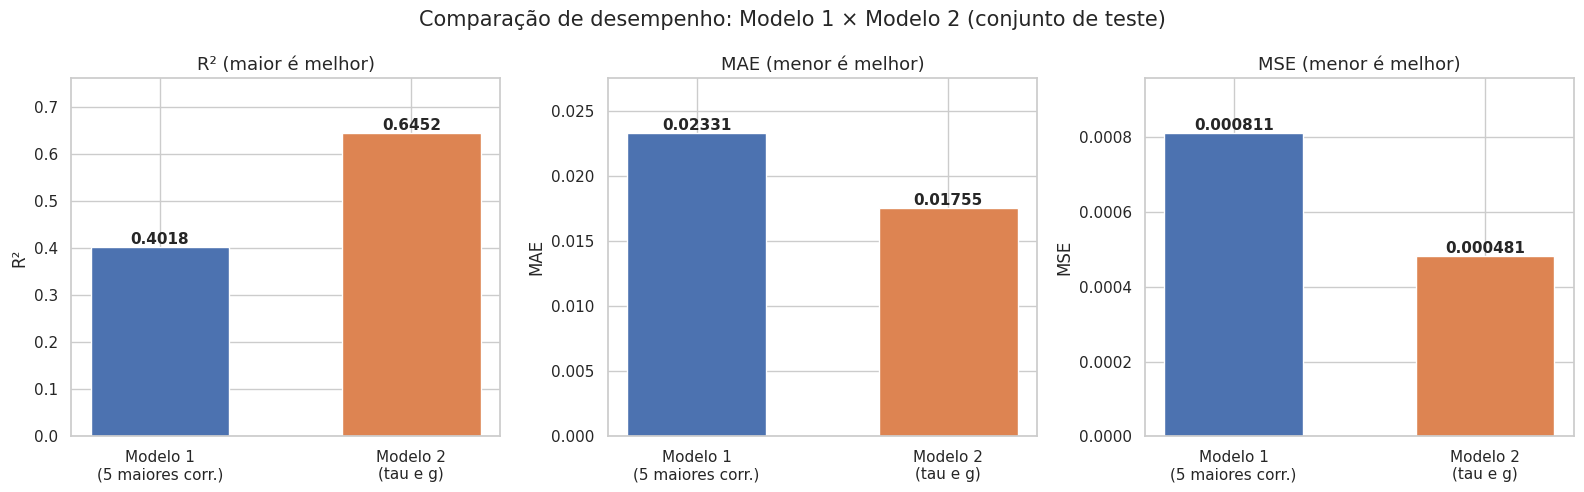

In [51]:
nomes = ["Modelo 1\n(5 maiores corr.)", "Modelo 2\n(tau e g)"]
cores = ["#4C72B0", "#DD8452"]

metricas = [
    ("R² (maior é melhor)",   [r2_modelo_1,  r2_modelo_2],  "R²",  "{:.4f}"),
    ("MAE (menor é melhor)",  [mae_modelo_1, mae_modelo_2], "MAE", "{:.5f}"),
    ("MSE (menor é melhor)",  [mse_modelo_1, mse_modelo_2], "MSE", "{:.6f}"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (titulo, valores, rotulo_y, fmt) in zip(axes, metricas):
    barras = ax.bar(nomes, valores, color=cores, width=0.55)
    ax.set_title(titulo, fontsize=13)
    ax.set_ylabel(rotulo_y)
    ax.set_ylim(0, max(valores) * 1.18)
    for barra, v in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width()/2, v, fmt.format(v),
                ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.suptitle("Comparação de desempenho: Modelo 1 × Modelo 2 (conjunto de teste)", fontsize=15)
plt.tight_layout()
plt.show()

## Análise comparativa final

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
O **Modelo 2 (tau e g)** teve o maior R²: **0,6452**, contra **0,4018** do Modelo 1. Ou seja, o Modelo 2 explica cerca de **64,5%** da variação de `stab`, enquanto o Modelo 1 explica cerca de **40,2%**, uma diferença de **+0,2435** (≈ 24 pontos percentuais).

**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
O **Modelo 2** teve o menor MAE: **0,01755**, contra **0,02331** do Modelo 1.

**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
O **Modelo 2** teve o menor MSE: **0,000481**, contra **0,000811** do Modelo 1, uma **redução de ≈ 40,7%**. A redução no MSE é maior que a do MAE porque o MSE eleva os erros ao quadrado. Isso mostra que o Modelo 2 reduziu especialmente as **previsões muito erradas**.

**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
**Sim.** As três métricas apontaram o **Modelo 2** como o melhor nas três métricas: maior R² (0,6452 × 0,4018), menor MAE (0,01755 × 0,02331) e menor MSE (0,000481 × 0,000811). Isso era esperado, já que as três medem o mesmo fenômeno (distância entre valor previsto e real) por ângulos diferentes: R² mede a proporção explicada, MAE o erro médio linear e MSE o erro médio quadrático.

**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
O desempenho melhorou nas três métricas**: R² subiu de 0,40 para 0,65, o MAE caiu ~25% e o MSE caiu ~41%.

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Escolheria o **Modelo 2 (tau e g)** porque ele teve o melhor desempenho nas três métricas:
R²: 0,6452 contra 0,4018, ou seja, o Modelo 2 explica mais a variação de stab.
MAE: 0,01755 contra 0,02331, ou seja, erra menos em média.
MSE: 0,000481 contra 0,000811, ou seja, comete menos erros grandes.